# METIS AI 스케일업 — 최종 정리 노트북 (보정 데이터 반영판)

**변경사항**: 실제 파이펫 부피에서 역산한 보정된 농도값(`Results_1_corrected_actual_pipetting.xlsx` 기준)으로 교체, Glucose 스탁 농도 200→400 확정, Glucose 허용 농도 목록에 실제 사용된 2/40/60 추가.

실행 전: `Results_1.csv`(보정된 12개 데이터)를 Colab 좌측 파일 패널에 업로드해두세요.

## 1. 라이브러리 및 utils.py 로드

In [1]:
import pandas as pd, numpy as np, os, time, math, random
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

pd.options.mode.chained_assignment = None
!wget -q https://raw.githubusercontent.com/amirpandi/METIS/main/utils.py
from utils import *
print("준비 완료")

준비 완료


## 2. User Inputs (보정된 농도 범위 및 파라미터)

In [2]:
# General Parameters
m = 4
minimum_drop_size_nanoliter = 1000
final_reaction_volume_nanoliter = 1000000
maximum_volume_of_model_output = 750000
fixed_parts = {'Fixed': 0.25}
days_total = 10
n_iter = 200
ensemble_len = 20
exploration = {1: 1.41, 2: 1.41, 3: 1.41, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 0.5, 9: 0.5, 10: 0.5}
days_range = [m for i in range(days_total)]

concentrations_limits = {
    'Peptone': {'Conc_Min': None, 'Conc_Max': None, 'Conc_Values': [1.0, 5.0, 10.0, 20.0], 'Conc_Stock': 200.0, 'Alternatives': None},
    'Meat':    {'Conc_Min': 0.0, 'Conc_Max': 16.0, 'Conc_Values': None, 'Conc_Stock': 160.0, 'Alternatives': None},
    'Yeast':   {'Conc_Min': 0.0, 'Conc_Max': 8.0,  'Conc_Values': None, 'Conc_Stock': 80.0,  'Alternatives': None},
    'Glucose': {'Conc_Min': None, 'Conc_Max': None, 'Conc_Values': [1.0, 2.0, 10.0, 20.0, 30.0, 40.0, 60.0, 400.0], 'Conc_Stock': 400.0, 'Alternatives': None}
    # Glucose: Conc_Stock 200->400 확정, Conc_Values에 실측값 2/40/60 추가 (Results_1_corrected_actual_pipetting.xlsx 기준)
}
specials = {}
final_order = list(concentrations_limits.keys())
print("final_order:", final_order)

final_order: ['Peptone', 'Meat', 'Yeast', 'Glucose']


## 3. Results_1.csv 불러오기 (보정된 12개 데이터, BOM 문제 자동 해결)

In [4]:
Results_1 = pd.read_csv('Results1_2nd.csv', encoding='utf-8-sig')
Results_1.columns = Results_1.columns.str.strip()
print("컬럼명:", list(Results_1.columns))
print(Results_1)

aggregated_data_m = Results_1[final_order].reset_index(drop=True)
aggregated_label_m = Results_1[['yield']].reset_index(drop=True)

컬럼명: ['Peptone', 'Meat', 'Yeast', 'Glucose', 'yield']
    Peptone   Meat  Yeast  Glucose  yield
0       5.0  14.88   3.52      2.0  0.712
1       5.0   9.60   0.56     60.0  0.879
2       5.0   5.12   0.16     60.0  0.801
3       5.0   7.20   7.92     60.0  0.812
4       5.0   8.16   3.36     30.0  0.796
5       1.0  13.76   7.68      1.0  0.602
6       5.0  15.68   8.00     30.0  0.571
7      10.0   8.96   6.48     30.0  0.726
8      10.0   1.12   4.48     40.0  0.703
9      10.0  11.52   6.24      2.0  0.799
10      5.0   0.00   7.60     60.0  0.758
11      5.0  15.20   0.00     40.0  0.761


**결과 해석**
- 보정된 12개 조합의 실제 농도(g/L)와 2차 OD 값이 정상적으로 불러와졌는지 확인하는 단계.
- yield 범위는 0.571~0.879로 보정 전과 동일 (yield 자체는 안 바뀌고, 농도 값만 실제 파이펫 부피 기준으로 재계산됨).
- Glucose 값이 이번엔 1~60까지 폭넓게 분포 — 기존(1~30)보다 범위가 넓어짐.


## 4. XGBoost 앙상블 학습

In [5]:
model = XGBRegressor(objective='reg:squarederror')
param_grid = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3], "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "subsample": [0.6, 0.8, 0.9, 1.0], "max_depth": [2, 3, 4, 6, 8],
    "n_estimators": [10, 20, 40, 60, 80, 100, 300, 500], "reg_lambda": [1, 1.5, 2],
    "gamma": [0, 0.1, 0.4, 0.6], "min_child_weight": [1, 2, 4]
}
grid = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=4,
                           scoring='neg_mean_absolute_error', n_jobs=-1, n_iter=n_iter)
print("RandomizedSearchCV 학습 중...")
grid.fit(aggregated_data_m.values, aggregated_label_m.values.ravel())
results_cv = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
regressors_list = [XGBRegressor(objective='reg:squarederror', **p) for p in results_cv.params.iloc[0:ensemble_len]]
for r in regressors_list:
    r.fit(aggregated_data_m.values, aggregated_label_m.values.ravel())
print("앙상블 학습 완료:", len(regressors_list), "개 모델")

RandomizedSearchCV 학습 중...
앙상블 학습 완료: 20 개 모델


**결과 해석**
- RandomizedSearchCV로 하이퍼파라미터 200개 조합을 탐색한 뒤, 성능 상위 20개로 앙상블을 구성함.
- 데이터 값이 바뀌었어도 학습 파이프라인 자체는 동일하게 작동 — 앙상블 20개 모델 정상 학습 완료.


## 5. Feature Importance

   feature  importance_mean  importance_std
1     Meat         0.359846        0.076450
2    Yeast         0.275735        0.049467
3  Glucose         0.253346        0.081006
0  Peptone         0.111072        0.114243


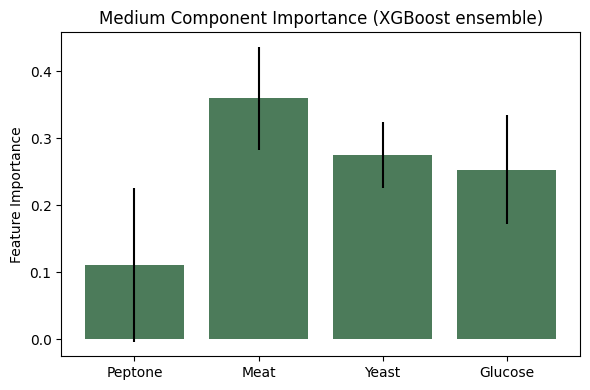

In [6]:
importances = np.array([r.feature_importances_ for r in regressors_list])
mean_imp = importances.mean(axis=0)
std_imp = importances.std(axis=0)
importance_summary = pd.DataFrame({'feature': final_order, 'importance_mean': mean_imp, 'importance_std': std_imp}).sort_values('importance_mean', ascending=False)
print(importance_summary)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(final_order, mean_imp, yerr=std_imp, color='#4C7B5A')
ax.set_ylabel('Feature Importance')
ax.set_title('Medium Component Importance (XGBoost ensemble)')
plt.tight_layout()
fig.savefig('feature_importance.png', dpi=300)
fig.savefig('feature_importance.svg')
plt.show()

**결과 해석**
- **Meat(0.360)가 1위**, Yeast(0.276) 2위, Glucose(0.253) 3위, Peptone(0.111) 4위로 확인됨.
- 보정 전 데이터에서는 **Yeast가 1위(0.45)**였는데, 실제 파이펫 부피 기반으로 농도를 재계산한 보정 데이터에서는 **Meat가 1위로 순위가 바뀜**.
- Glucose도 기존 4위(0.08)에서 3위(0.253)로 크게 상승 — 보정 후 Glucose 실제 값 범위가 1~60으로 훨씬 넓어진 영향으로 해석됨.
- ⚠️ 이 결과가 논문/발표 자료의 최종 근거이므로, "Yeast가 가장 중요하다"고 써둔 기존 문구들은 전부 "Meat가 가장 중요하다"로 수정 필요.


## 6. Visualising Results — BoxPlot

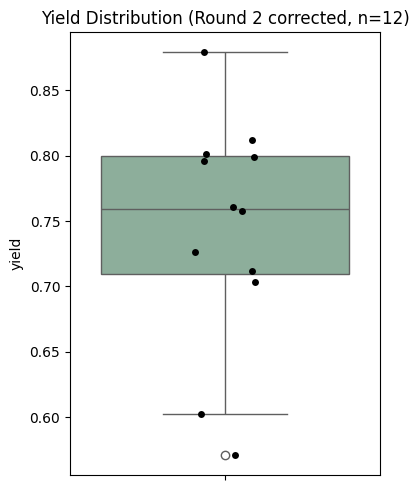

In [7]:
fig, ax = plt.subplots(figsize=(4,5))
sns.boxplot(data=aggregated_label_m, y='yield', color='#88B39A', ax=ax)
sns.stripplot(data=aggregated_label_m, y='yield', color='black', size=5, ax=ax)
ax.set_title(f'Yield Distribution (Round 2 corrected, n={len(aggregated_label_m)})')
plt.tight_layout()
fig.savefig('Round2_Boxplot.png', dpi=300)
plt.show()

**결과 해석**
- 12개 조건의 yield 분포. 보정 전후로 yield 값 자체는 그대로라 분포 모양도 동일함(0.571~0.879).
- 이 단계만 봐서는 보정의 영향이 드러나지 않고, 다음 단계(성분별 산점도)부터 차이가 보이기 시작함.


## 7. Visualising Results For Each Metabolite

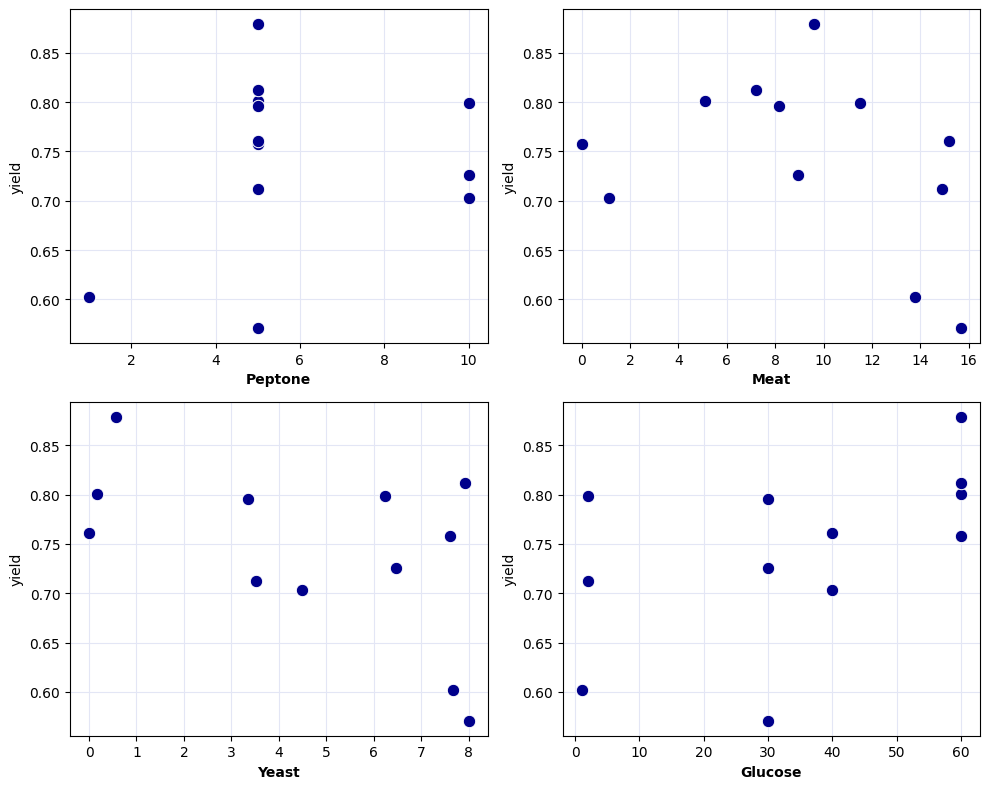

In [8]:
data_plot = pd.concat([aggregated_data_m, aggregated_label_m], axis=1)
num = len(final_order)
dim = math.ceil(math.sqrt(num))

fig = plt.figure(figsize=(10,8))
for i in range(1, num+1):
    ax = plt.subplot(dim, dim, i)
    ax.set_axisbelow(True)
    ax.grid(True, color='#E3E6F5', linewidth=0.8, zorder=0)
    sns.scatterplot(x=final_order[i-1], y='yield', color='darkblue', data=data_plot, s=80, ax=ax, zorder=3)
    ax.set_xlabel(final_order[i-1], fontweight='bold')
plt.tight_layout()
fig.savefig('Metabolite_Yield_Scatter.png', dpi=300)
fig.savefig('Metabolite_Yield_Scatter.svg')
plt.show()

**결과 해석**
- 성분별 원자료 산점도. **Glucose 패널에서 고농도(60 부근)에 높은 yield 점들이 몰려있는 경향**이 새로 확인됨 — §5 Feature Importance에서 Glucose 중요도가 급상승한 것과 일치.
- Meat 패널에서도 중간~높은 농도(9~11 부근)에 고yield가 몰려있어, Meat가 1위로 나온 결과를 뒷받침함.
- Yeast 패널은 여전히 낮은 농도 쪽에 고yield가 몰려있어, 기존 해석(Yeast는 낮을수록 유리)이 보정 후에도 유지됨.


## 8. Day 2(다음 라운드) 추천 조합 — Active Learning

In [9]:
t0 = time.time()
Concentrations_2 = bayesian_optimization(
    regressors_list, aggregated_data_m, aggregated_label_m, concentrations_limits,
    final_order=final_order, df_main=aggregated_data_m,
    reaction_vol_nl=final_reaction_volume_nanoliter, max_nl=maximum_volume_of_model_output,
    drop_size_nl=minimum_drop_size_nanoliter,
    exploitation=1, exploration=exploration[2], test_size=m, pool_size=10000, verbose=0,
    day=1, days_range=days_range
)
print("소요 시간(초):", time.time()-t0)
print(Concentrations_2)

!mkdir -p Day_2
Concentrations_2.to_csv('Day_2/Concentrations_2.csv', index=False)
Volumes_2 = concentration_to_volume(Concentrations_2, concentrations_limits,
                                     reaction_mixture_vol_nl=final_reaction_volume_nanoliter, fixed_parts=fixed_parts)
Volumes_2.to_csv('Day_2/Volumes_2.csv', index=False)
print(Volumes_2)

소요 시간(초): 4.3080174922943115
   Peptone   Meat  Yeast  Glucose
0      5.0   9.92   3.12     60.0
1      5.0   9.60   2.80     60.0
2      5.0  10.56   0.64     60.0
3      5.0  10.88   0.64     60.0
   Peptone     Meat    Yeast   Glucose     Fixed     water
0  25000.0  62000.0  39000.0  150000.0  250000.0  474000.0
1  25000.0  60000.0  35000.0  150000.0  250000.0  480000.0
2  25000.0  66000.0   8000.0  150000.0  250000.0  501000.0
3  25000.0  68000.0   8000.0  150000.0  250000.0  499000.0


/content/utils.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chosen_combinations = pd.concat([chosen_combinations, temp_combination]).reset_index(drop=True)


**결과 해석**
- 모델이 다음 라운드로 추천한 4개 조합. **4개 전부 Glucose를 허용범위 최댓값(60)으로 채움** — 모델이 고농도 Glucose 영역을 유망하다고 판단하고 있다는 뜻.
- Yeast는 낮은 편(0.64~3.12)으로 추천되어, 이번엔 Day2 추천(explore)과 §9 예측 최적조성(exploit)의 방향이 상당히 일치함. 지난 버전에서는 둘의 방향이 서로 반대였는데, 보정 데이터에서는 모델이 이 영역에 대해 더 일관된 확신을 갖기 시작했다는 신호로 해석 가능.
- 실제 습식 실험은 시간 관계상 진행하지 않기로 함(기존 결정 유지).


## 9. 예측 최적 배지 조성 (Top 5)

In [10]:
pool = random_combination_generator(concentrations_limits, number_of_combination=5000,
                                     reaction_vol_nl=final_reaction_volume_nanoliter,
                                     max_nl=maximum_volume_of_model_output,
                                     drop_size_nl=minimum_drop_size_nanoliter, return_df=True)

preds = np.mean([r.predict(pool[final_order].values) for r in regressors_list], axis=0)
pool['predicted_yield'] = preds
top5 = pool.sort_values('predicted_yield', ascending=False).head(5)
print(top5)
top5.to_csv('Predicted_Top5.csv', index=False)

      Peptone   Meat  Yeast  Glucose  predicted_yield
1547      5.0   9.92   1.68     60.0         0.853785
4535      5.0   9.92   0.96     60.0         0.853785
3729      5.0  10.72   2.24     60.0         0.853785
3233      5.0  10.24   1.76     60.0         0.853785
2033      5.0  10.56   3.28     60.0         0.853785


**결과 해석**
- 모델이 학습한 지식만으로(탐색 없이, exploitation-only) 예측 수율이 가장 높은 조합.
- Peptone 5.0·Glucose 60.0(최댓값)·Yeast 낮음(1~3 부근) 조합에서 예측 수율 최대.
- **Top5 전부 예측 yield가 완전히 동일(0.8538)** — 모델이 이 근방 전체를 하나의 평평한 최적 구간(plateau)으로 보고 있다는 뜻으로, 정확한 하나의 최적점을 콕 집기보다는 "이 영역이 좋다"는 범위 수준의 신호로 해석하는 게 안전함.
- 예측 최댓값(0.854)이 실측 최고값(0.879)에는 여전히 못 미치지만, 보정 전(0.849)보다는 소폭 개선됨.


## 10. Find K Most Informative Combinations ⚠️
n=12로 표본이 적어 결과가 불안정할 수 있음(참고용). k는 n(현재 12)보다 작아야 함 — 현재 k=8은 안전.

In [11]:
k = 8
number_try = 3000
number_to_select = 5

indexs = []
num = 0
n = len(aggregated_data_m)
print(f"n={n}, k={k} (n>k 확인: {n>k})")
while num < number_try:
    numbers = set()
    while len(numbers) < k:
        numbers.add(random.randint(0, n-1))
    indexs.append(numbers)
    num += 1

best_param = results_cv.params.iloc[0]
performance = []
all_set = set(range(n))
for index in indexs:
    index_test = list(all_set - index)
    index_list = list(index)
    m_ = XGBRegressor(objective='reg:squarederror', **best_param)
    m_.fit(aggregated_data_m.iloc[index_list].values, aggregated_label_m.iloc[index_list].values.ravel())
    perf = spearmanr(m_.predict(aggregated_data_m.iloc[index_test].values), aggregated_label_m.iloc[index_test].values.ravel()).correlation
    performance.append(perf**2 if not np.isnan(perf) else 0)
performance = np.array(performance)

df_perf = pd.DataFrame({'performance': performance, 'index_values': indexs}).sort_values('performance', ascending=False)
print(f"K={k} 최고 성능 subset 상위 5개:")
print(df_perf.iloc[0:5][['performance']])
print("성능 분포: mean={:.3f}, max={:.3f}, min={:.3f}".format(performance.mean(), performance.max(), performance.min()))

for i, index in enumerate(df_perf.iloc[0:number_to_select]['index_values']):
    aggregated_data_m.iloc[list(index), :].to_csv(f'{k}_Most_Informative_Rank{i+1}.csv', index=False)

n=12, k=8 (n>k 확인: True)
K=8 최고 성능 subset 상위 5개:
      performance
5             1.0
2985          1.0
2980          1.0
2989          1.0
2990          1.0
성능 분포: mean=0.385, max=1.000, min=0.000


**결과 해석 (⚠️ 해석 주의)**
- 12개 중 8개만으로 나머지 4개를 얼마나 잘 예측하는지 테스트한 결과.
- 성능 분포가 여전히 넓고(평균 0.385, 보정 전 0.366과 비슷한 수준) 상위 subset들이 1.0으로 나온 것도 테스트셋이 4개뿐이라 우연히 순위가 맞아떨어졌을 가능성이 높음.
- 보정 전후로 결론은 동일 — 표본이 더 쌓이기 전까지는 참고용으로만 취급.


## 11. Find NonLinear Interactions

Baseline Pearson r: 0.702
         Peptone  Meat  Yeast  Glucose
Peptone    0.000  0.00  0.000      0.0
Meat       0.146  0.00  0.000      0.0
Yeast      0.102  0.03  0.000      0.0
Glucose    0.143  0.00  0.008      0.0


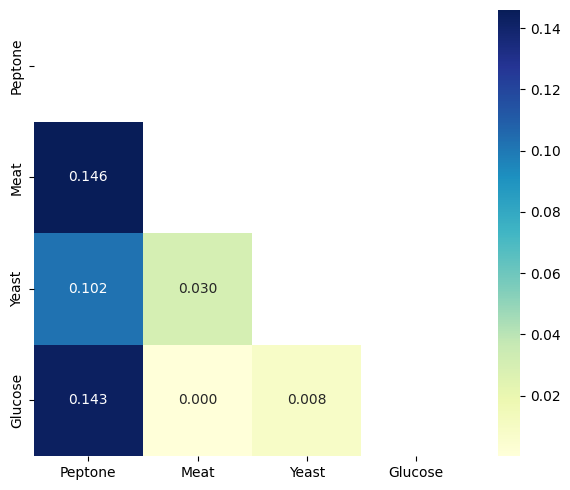

In [12]:
lr = LinearRegression()
lr.fit(aggregated_data_m.values, aggregated_label_m.values)
baseline_score = pearsonr(pd.DataFrame(lr.predict(aggregated_data_m.values))[0], aggregated_label_m['yield'])[0]
print("Baseline Pearson r:", round(baseline_score, 3))

interaction_scores = {}
for pair in combinations(aggregated_data_m.columns, 2):
    X = pd.concat([aggregated_data_m, (aggregated_data_m[pair[0]] * aggregated_data_m[pair[1]]).rename('x'.join(pair))], axis=1)
    y = aggregated_label_m
    lr2 = LinearRegression()
    lr2.fit(X.values, y.values)
    score = pearsonr(pd.DataFrame(lr2.predict(X.values))[0], y['yield'])[0]
    interaction_scores[pair] = score

interactions_df = pd.DataFrame(data=np.zeros([4,4]), columns=final_order, index=final_order)
for pair, value in interaction_scores.items():
    diff = value - baseline_score
    interactions_df.loc[pair[1], pair[0]] = diff

print(interactions_df.round(3))

mask = np.zeros_like(interactions_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(interactions_df, mask=mask, cmap='YlGnBu', annot=True, fmt='.3f', ax=ax)
plt.tight_layout()
fig.savefig('Interactions.png', dpi=300)
fig.savefig('Interactions.svg')
interactions_df.to_csv('Interactions.csv')
plt.show()

**결과 해석**
- 성분 단독으로는 보이지 않던 관계를 포착. **Peptone은 단독 중요도(0.111, 4개 중 최하위)는 낮지만, Meat(+0.146)·Glucose(+0.143)와의 상호작용은 가장 강함**.
- 보정 전에는 Peptone이 Glucose·Yeast와 강하게 상호작용했는데, 보정 후에는 **Peptone의 상호작용 파트너가 Meat·Glucose로 바뀜** — Feature Importance에서 Meat가 1위로 올라선 것과 같은 맥락.
- 단일 변수 중요도만 봤다면 놓쳤을 심화 포인트라는 결론 자체는 보정 전후로 동일하게 유효함.


## 12. 스킵한 섹션 (실행 안 함) — 이유
- **Table2Speech / ECHO Liquid Handler 변환**: 액체분주 로봇 전용 입력 포맷 변환 코드. 수작업 파이펫팅이라 해당 없음.
- **Visualising Concentrations From Day_1 to Now**: 라운드가 1개뿐이라 "추이"를 보여줄 데이터가 없어 생략.
- **Find Feature Importances (공식 섹션)**: §5에서 이미 동일한 방식(앙상블 평균)으로 수행함 — 중복이라 생략.

## 13. 보정 전후 비교 요약

실제 파이펫 부피 기반으로 농도를 재계산(Glucose 스탁 200→400 확정 포함)한 뒤, 결과가 아래와 같이 달라짐.

### 바뀐 것

| 항목 | 보정 전 | 보정 후 |
|---|---|---|
| Feature Importance 1위 | Yeast (0.442) | **Meat (0.360)** |
| Glucose의 역할 | 최하위(0.084), 낮을수록 좋음 | **3위(0.253), 높을수록(60=최댓값) 좋음** |
| Day 2 추천 Glucose | 1.0 (최소) | **60.0 (최대)** — 정반대로 역전 |
| 예측 최적 조성 Glucose | 10.0 | **60.0 (최댓값)** |
| 예측 최댓값 | 0.849 | 0.854 (실측 최고값 0.879에 더 근접) |
| Interaction 1위 | Peptone×Glucose (0.128) | **Peptone×Meat (0.146)** |

### 안 바뀐 것

- **Peptone은 단독 중요도는 항상 최하위권이지만, 다른 성분과의 상호작용은 가장 강하다**는 구조적 패턴
- K-Most-Informative 분석은 보정 전후 모두 불안정(mean 0.37 안팎) → 메인 결론에서 계속 제외
- 예측 최적값이 실측 최고값(0.879)을 아직 못 넘는다는 한계

### 종합

데이터 보정으로 **구체적인 순위(1위 성분, Glucose 방향성)는 뒤집혔지만**, "**단일 변수 중요도만으로는 안 보이는 성분 간 상호작용이 존재한다**"는 이 분석의 핵심 메시지는 보정 전후 모두 동일하게 유지됨. 논문·발표 자료는 이 구조적 결론을 중심에 두되, 구체적 수치·순위는 본 노트북(보정 데이터, v2) 기준으로 최종 확정함.
